In [10]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import torchvision
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torch.nn.functional as F

In [11]:
# 数据预处理：将图像转换为张量并进行归一化
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))  # 归一化到 [0, 1] 范围
])

# 加载训练集和测试集
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)


In [12]:
def train(model, train_loader, criterion, optimizer, num_epochs=5):
    model.train()
    acc = []
    for epoch in range(num_epochs):
        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in train_loader:
            # 将图像调整为 (batch_size, sequence_length, input_size) 形式
            images = images.view(-1, 28, 28).to(device)  # 每张图片的28行作为时间步

            # 清零梯度
            optimizer.zero_grad()

            # 前向传播
            outputs,attention_weights = model(images)

            # 计算损失
            loss = criterion(outputs, labels.to(device))

            # 反向传播并优化
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

            # 计算准确率
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels.to(device)).sum().item()
        acc.append(round(correct*100/total,2))

        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss/len(train_loader):.4f}, Accuracy: {100 * correct / total:.2f}%")
    plt.plot(range(len(acc)),acc)
    plt.xlabel('epoch')
    plt.ylabel('acc')
    return attention_weights

In [13]:
def test(model, test_loader):
    model.eval()  # 设置为评估模式
    correct = 0
    total = 0
    with torch.no_grad():  # 不计算梯度
        for images, labels in test_loader:
            images = images.view(-1, 28, 28).to(device)
            outputs,attention_weights = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels.to(device)).sum().item()

    print(f"Test Accuracy: {100 * correct / total:.2f}%")
    return attention_weights


### 定义自注意模块

In [14]:
# 自注意力模块
class SelfAttention(nn.Module):
    def __init__(self, hidden_size):
        super(SelfAttention, self).__init__()
        self.hidden_size = hidden_size
        self.attention_weights = nn.Linear(hidden_size, 1, bias=False)

    def forward(self, rnn_output):
        # rnn_output: (batch_size, seq_len, hidden_size)
        attention_scores = self.attention_weights(rnn_output)  # (batch_size, seq_len, 1)    #加性模型
        attention_scores = attention_scores.squeeze(-1)  # (batch_size, seq_len)
        attention_weights = F.softmax(attention_scores, dim=1)  # (batch_size, seq_len)
        
        # 加权求和
        attention_output = torch.sum(rnn_output * attention_weights.unsqueeze(-1), dim=1)  # (batch_size, hidden_size)
        return attention_output, attention_weights

# 带自注意力机制的RNN模型
class RNNWithAttention(nn.Module):
    def __init__(self, input_size=28, hidden_size=128, output_size=10, num_layers=1):
        super(RNNWithAttention, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.rnn = nn.RNN(input_size, hidden_size, num_layers, batch_first=True)
        self.attention = SelfAttention(hidden_size)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        out, _ = self.rnn(x, h0)  # (batch_size, seq_len, hidden_size)
        
        # 自注意力机制
        attention_output, attention_weights = self.attention(out)  # (batch_size, hidden_size), (batch_size, seq_len)
#         attention_output, attention_weights = out,None
        
        # 全连接层
        output = self.fc(attention_output)  # (batch_size, output_size)
        return output, attention_weights

# 可视化注意力得分
def visualize_attention(attention_weights, sequence_length):
    plt.figure(figsize=(10, 6))
    plt.imshow(attention_weights.detach().cpu().numpy(), cmap='viridis', aspect='auto')
    plt.colorbar(label='Attention Score')
    plt.xlabel('Sequence Length')
    plt.ylabel('Batch Index')
    plt.title('Attention Scores Visualization')
    plt.show()


Epoch [1/5], Loss: 0.6793, Accuracy: 78.50%
Epoch [2/5], Loss: 0.2237, Accuracy: 93.59%
Epoch [3/5], Loss: 0.1628, Accuracy: 95.31%
Epoch [4/5], Loss: 0.1325, Accuracy: 96.15%
Epoch [5/5], Loss: 0.1142, Accuracy: 96.66%
Test Accuracy: 94.21%


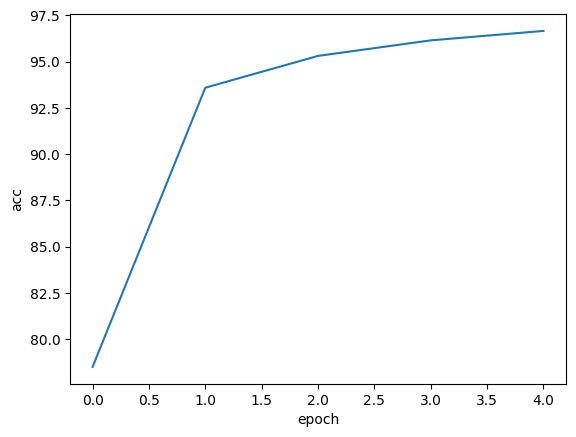

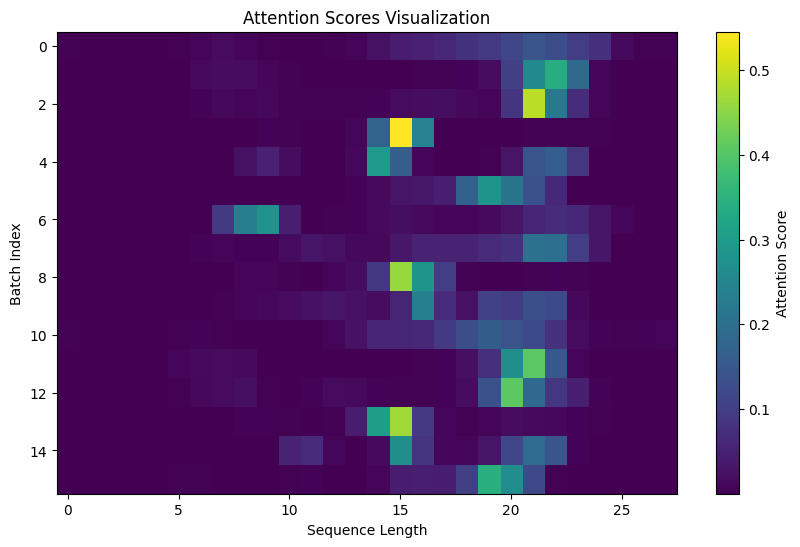

In [15]:
# 4. 模型训练与测试
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


batch_size = 16
seq_len = 28
input_size = 28
hidden_size = 128
output_size = 10
num_layers = 1

# 模型和输入
model = RNNWithAttention(input_size, hidden_size, output_size, num_layers).to(device)

# 初始化模型、损失函数、优化器
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 训练和评估模型
attention_weights = train(model, train_loader, criterion, optimizer,num_epochs = 5)
attention_weights = test(model, test_loader)

torch.save(model.state_dict(),'rnn.pth')
visualize_attention(attention_weights, seq_len)

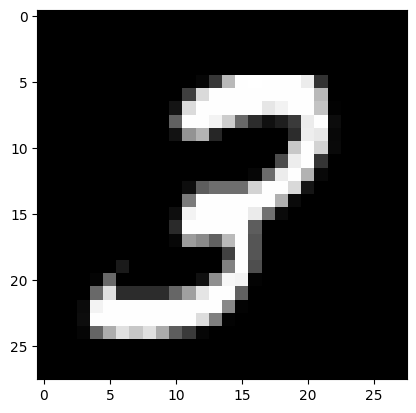

In [16]:
# 从 DataLoader 中取出一个批次
data_iter = iter(train_loader)
images, labels = next(data_iter)
image_ = images[6]
plt.imshow(image_.permute(1,2,0),cmap='gray')
plt.show()

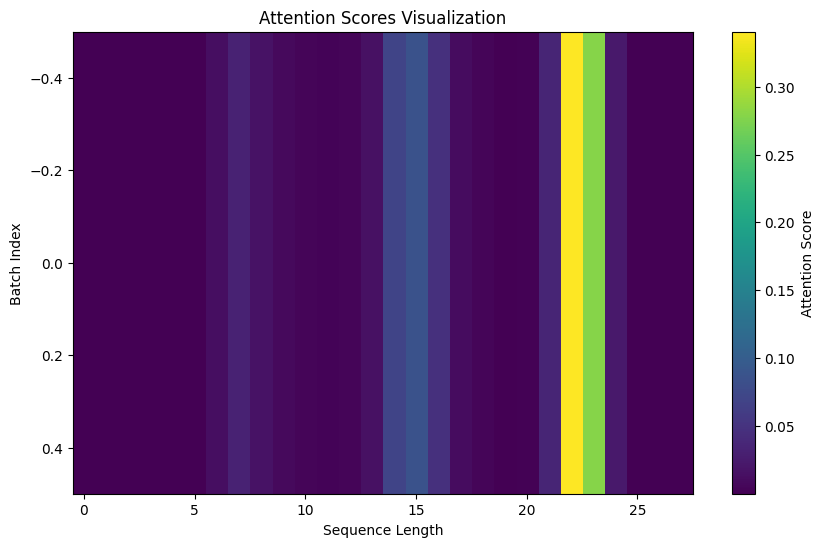

In [18]:
image_ = image_.to(device)
model = RNNWithAttention(input_size, hidden_size, output_size, num_layers)
model.load_state_dict(torch.load('cnn.pth'))
model = model.to(device)
# print(image_.device,model.device)
outputs,attention_weights = model(image_)

visualize_attention(attention_weights[0:1,:], seq_len)

In [ ]:
print(torch.cuda.is_available())